imports


In [4]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


 Model Definitions

In [6]:
class SimCLR(nn.Module):
    def __init__(self, base_model='resnet18', out_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = torchvision.models.resnet18(weights=None)
        self.encoder.fc = nn.Identity()
        self.projection = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)
        z = self.projection(h)
        return h, z

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="sum")
    
    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)
        sim = torch.mm(z, z.t()) / self.temperature
        sim = sim - torch.eye(2*batch_size, device=sim.device) * 1e9
        labels = torch.cat([torch.arange(batch_size, 2*batch_size), torch.arange(batch_size)], dim=0).to(sim.device)
        loss = self.criterion(sim, labels) / (2 * batch_size)
        return loss

print("Models defined successfully")

Models defined successfully


Dataset Loading

In [7]:
class SimCLRDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        return self.transform(img), self.transform(img)

def get_simclr_transforms():
    transform = transforms.Compose([
        transforms.RandomResizedCrop(32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    return transform

def load_cifar10():
    transform = get_simclr_transforms()
    base_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, 
        transform=None
    )
    trainset = SimCLRDataset(base_dataset, transform)
    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=256, shuffle=True, 
        num_workers=2, drop_last=True
    )
    return trainset, trainloader

# Load dataset
trainset, trainloader = load_cifar10()
print(f"Dataset loaded: {len(trainset)} images")

Dataset loaded: 50000 images


Training Function

In [8]:
def train_simclr(model, trainloader, epochs=500, device='cpu', checkpoint_path='simclr_checkpoint.pth'):
    model.to(device)
    model.requires_grad_(True)   
    model.train()               
    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
    criterion = NTXentLoss(temperature=0.5)

    start_epoch = 0
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']
        print(f"Resumed from epoch {start_epoch}")

    model.train()   
    for epoch in range(start_epoch, epochs):
        total_loss = 0
        for batch_idx, (x_i, x_j) in enumerate(trainloader):
            x_i, x_j = x_i.to(device), x_j.to(device)

            optimizer.zero_grad()
            _, z_i = model(x_i)
            _, z_j = model(x_j)
            loss = criterion(z_i, z_j)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(trainloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, checkpoint_path)
            print(f"Checkpoint saved at epoch {epoch+1}")

    return model

print("Training function defined")


Training function defined


Train SimCLR

In [9]:
torch.set_grad_enabled(True)
CHECKPOINT_PATH = '/kaggle/working/simclr_checkpoint.pth'

model = SimCLR()
trained_model = train_simclr(
    model, trainloader, epochs=500,
    device=device,
    checkpoint_path=CHECKPOINT_PATH
)

torch.save(trained_model.state_dict(), '/kaggle/working/simclr_final.pth')
print("Final model saved")

Resumed from epoch 500
Final model saved


verify checkpoints

In [10]:
import os
ckpt = '/kaggle/working/simclr_checkpoint.pth'
if os.path.exists(ckpt):
    checkpoint = torch.load(ckpt)
    print(f"Checkpoint found, Saved at epoch {checkpoint['epoch']}")
else:
    print("No checkpoint found, will train from scratch")

Checkpoint found, Saved at epoch 500


Extract Embeddings

In [11]:
def extract_embeddings(model, dataset, device='cpu', batch_size=512, normalize=False):
    model.eval()
    model.to(device)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    class TransformDataset(torch.utils.data.Dataset):
        def __init__(self, ds, tf):
            self.ds, self.tf = ds, tf
        def __len__(self):
            return len(self.ds)
        def __getitem__(self, idx):
            img, label = self.ds[idx]
            return self.tf(img), label

    loader = torch.utils.data.DataLoader(
        TransformDataset(dataset, transform),
        batch_size=batch_size, shuffle=False, num_workers=2
    )

    embeddings, labels = [], []
    print("Extracting embeddings...")
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(loader):
            imgs = imgs.to(device)
            h, _ = model(imgs)
            embeddings.append(h.cpu().numpy())
            labels.append(lbls.numpy())
            if (i + 1) % 10 == 0:
                print(f"Processed {min((i+1)*batch_size, len(dataset))}/{len(dataset)} images")

    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    if normalize:
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        embeddings = embeddings / (norms + 1e-8)
        print("Embeddings L2-normalized.")

    print(f"Done. Embeddings shape: {embeddings.shape}")
    return embeddings, labels

base_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False)
embeddings, true_labels = extract_embeddings(trained_model, base_dataset, device=device, normalize=False)
np.save('/kaggle/working/embeddings.npy', embeddings)
np.save('/kaggle/working/true_labels.npy', true_labels)
print("Embeddings saved")


Extracting embeddings...
Processed 5120/50000 images
Processed 10240/50000 images
Processed 15360/50000 images
Processed 20480/50000 images
Processed 25600/50000 images
Processed 30720/50000 images
Processed 35840/50000 images
Processed 40960/50000 images
Processed 46080/50000 images
Done. Embeddings shape: (50000, 512)
Embeddings saved


Clustering +  Typicality (Original TPCRP)

In [12]:
def cluster_embeddings(embeddings, n_clusters=10):
    print(f"Clustering {len(embeddings)} embeddings into {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)
    return cluster_labels, kmeans.cluster_centers_

def compute_typicality(embeddings, cluster_labels, n_clusters=10, K=20):
    selected_indices = []
    
    print(f"Computing typicality for {n_clusters} clusters...")
    for c in range(n_clusters):
        cluster_mask = cluster_labels == c
        cluster_embeddings = embeddings[cluster_mask]
        
        if len(cluster_embeddings) == 0:
            continue
        
        nbrs = NearestNeighbors(
            n_neighbors=min(K, len(cluster_embeddings)), 
            algorithm='ball_tree'
        ).fit(cluster_embeddings)
        distances, _ = nbrs.kneighbors(cluster_embeddings)
        
        mean_distances = np.mean(distances, axis=1)
        typicalities = 1 / (mean_distances + 1e-8)
        
        best_idx_in_cluster = np.argmax(typicalities)
        global_idx = np.where(cluster_mask)[0][best_idx_in_cluster]
        selected_indices.append(global_idx)
        
        print(f"Cluster {c}: selected index {global_idx}, typicality {typicalities[best_idx_in_cluster]:.4f}")
    
    return selected_indices

# Perform clustering
cluster_labels, centers = cluster_embeddings(embeddings, n_clusters=10)
print(f"Clustering completed. Cluster sizes: {np.bincount(cluster_labels)}")

# Select typical examples
selected_indices = compute_typicality(embeddings, cluster_labels, n_clusters=10)
print(f"Selected {len(selected_indices)} typical examples: {selected_indices}")

# Save results
np.save('selected_indices.npy', selected_indices)
np.save('cluster_labels.npy', cluster_labels)
print("Results saved")

Clustering 50000 embeddings into 10 clusters...
Clustering completed. Cluster sizes: [4890 4974 5817 5095 7283 4776 4503 5463 4282 2917]
Computing typicality for 10 clusters...
Cluster 0: selected index 26369, typicality 0.1486
Cluster 1: selected index 8015, typicality 0.1471
Cluster 2: selected index 17387, typicality 0.1801
Cluster 3: selected index 1129, typicality 0.1386
Cluster 4: selected index 25652, typicality 0.3104
Cluster 5: selected index 39686, typicality 0.1852
Cluster 6: selected index 26256, typicality 0.1607
Cluster 7: selected index 44322, typicality 0.1334
Cluster 8: selected index 46237, typicality 0.2243
Cluster 9: selected index 23581, typicality 0.1910
Selected 10 typical examples: [np.int64(26369), np.int64(8015), np.int64(17387), np.int64(1129), np.int64(25652), np.int64(39686), np.int64(26256), np.int64(44322), np.int64(46237), np.int64(23581)]
Results saved


Evaluation Original TPCRP

In [13]:
def evaluate_selection(selected_indices, base_dataset):
    selected_labels = [base_dataset[idx][1] for idx in selected_indices]
    print(f"Selected examples labels: {selected_labels}")
    
    unique, counts = np.unique(selected_labels, return_counts=True)
    print(f"Class distribution: {dict(zip(unique, counts))}")
    
    return selected_labels

selected_labels = evaluate_selection(selected_indices, base_dataset)

# Compare with random selection
np.random.seed(42)
random_indices = np.random.choice(len(base_dataset), size=len(selected_indices), replace=False)
random_labels = evaluate_selection(random_indices, base_dataset)

print(f"\nTPCRP selection covers {len(set(selected_labels))} classes")
print(f"Random selection covers {len(set(random_labels))} classes")

print("\n=== TPCRP Implementation Completed Successfully ===")

Selected examples labels: [8, 6, 0, 2, 1, 2, 7, 3, 1, 0]
Class distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(2), np.int64(2): np.int64(2), np.int64(3): np.int64(1), np.int64(6): np.int64(1), np.int64(7): np.int64(1), np.int64(8): np.int64(1)}
Selected examples labels: [7, 8, 0, 6, 1, 6, 8, 0, 6, 5]
Class distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(5): np.int64(1), np.int64(6): np.int64(3), np.int64(7): np.int64(1), np.int64(8): np.int64(2)}

TPCRP selection covers 7 classes
Random selection covers 6 classes

=== TPCRP Implementation Completed Successfully ===


modified pipeline

In [14]:
BUDGET= 10

def compute_typicality_modified(embeddings, cluster_labels, budget=10, K=20):

    n_clusters = len(np.unique(cluster_labels))
    
    # Compute cluster centers
    centers = np.array([
        embeddings[cluster_labels == c].mean(axis=0)
        for c in range(n_clusters)
    ])
    
    # Greedy diversity: pick cluster whose center is farthest from already selected
    selected_clusters = []
    # Start with the largest cluster
    sizes = [np.sum(cluster_labels == c) for c in range(n_clusters)]
    selected_clusters.append(np.argmax(sizes))
    
    while len(selected_clusters) < budget:
        selected_centers = centers[selected_clusters]
        # For each remaining cluster, find its min distance to any selected center
        remaining = [c for c in range(n_clusters) if c not in selected_clusters]
        min_dists = []
        for c in remaining:
            dists = np.linalg.norm(selected_centers - centers[c], axis=1)
            min_dists.append(np.min(dists))
        # Pick the cluster that is farthest from all selected clusters
        chosen = remaining[np.argmax(min_dists)]
        selected_clusters.append(chosen)
    
    # From each selected cluster, pick the most typical point
    selected_indices = []
    for c in selected_clusters:
        cluster_mask = cluster_labels == c
        cluster_embs = embeddings[cluster_mask]
        k = min(K, len(cluster_embs))
        nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(cluster_embs)
        distances, _ = nbrs.kneighbors(cluster_embs)
        typicalities = 1 / (np.mean(distances, axis=1) + 1e-8)
        best = np.argmax(typicalities)
        global_idx = np.where(cluster_mask)[0][best]
        selected_indices.append(global_idx)
    
    return selected_indices

# L2-normalize
embeddings_norm, _ = extract_embeddings(trained_model, base_dataset, device=device, normalize=True)

# Try different cluster counts with greedy diversity
best_coverage = 0
best_result = None
best_n = 200

for n_clusters in [50,100,200,500,650,800]:
    print(f"\nTrying {n_clusters} clusters (greedy diversity)")
    cl, _ = cluster_embeddings(embeddings_norm, n_clusters=n_clusters)
    sel = compute_typicality_modified(embeddings_norm, cl, budget=BUDGET)
    lbls = [base_dataset[i][1] for i in sel]
    coverage = len(set(lbls))
    print(f"   {coverage}/10 classes: {sorted(set(lbls))}")
    if coverage > best_coverage:
        best_coverage = coverage
        best_result = (sel, lbls, cl)
        best_n = n_clusters

selected_indices_mod, selected_labels_mod, cluster_labels_mod = best_result
print(f"\nBest: {best_n} clusters  {best_coverage}/10 classes")
print(f"Original TPCRP: {len(set(selected_labels))}/10  {sorted(set(selected_labels))}")
print(f"Modified TPCRP: {len(set(selected_labels_mod))}/10  {sorted(set(selected_labels_mod))}")


Extracting embeddings...
Processed 5120/50000 images
Processed 10240/50000 images
Processed 15360/50000 images
Processed 20480/50000 images
Processed 25600/50000 images
Processed 30720/50000 images
Processed 35840/50000 images
Processed 40960/50000 images
Processed 46080/50000 images
Embeddings L2-normalized.
Done. Embeddings shape: (50000, 512)

Trying 50 clusters (greedy diversity)
Clustering 50000 embeddings into 50 clusters...
   5/10 classes: [0, 1, 5, 7, 8]

Trying 100 clusters (greedy diversity)
Clustering 50000 embeddings into 100 clusters...
   7/10 classes: [0, 1, 4, 5, 6, 7, 8]

Trying 200 clusters (greedy diversity)
Clustering 50000 embeddings into 200 clusters...
   8/10 classes: [0, 1, 4, 5, 6, 7, 8, 9]

Trying 500 clusters (greedy diversity)
Clustering 50000 embeddings into 500 clusters...
   8/10 classes: [0, 1, 2, 5, 6, 7, 8, 9]

Trying 650 clusters (greedy diversity)
Clustering 50000 embeddings into 650 clusters...
   7/10 classes: [0, 1, 2, 4, 5, 7, 8]

Trying 800 cl

 Fully Supervised Evaluation

In [15]:
import torch.nn.functional as F

def train_fully_supervised(selected_indices, base_dataset, device, epochs=200):
    
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])

    class SubsetDataset(torch.utils.data.Dataset):
        def __init__(self, dataset, indices, transform):
            self.dataset = dataset
            self.indices = indices
            self.transform = transform
        def __len__(self):
            return len(self.indices)
        def __getitem__(self, idx):
            img, label = self.dataset[self.indices[idx]]
            return self.transform(img), label

    labeled_set = SubsetDataset(base_dataset, selected_indices, transform_train)
    labeled_loader = torch.utils.data.DataLoader(labeled_set, batch_size=10, shuffle=True)

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

    # ResNet18 (not pretrained)
    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(512, 10)
    model.to(device)

    optimizer = torch.optim.SGD(model.parameters(), lr=0.025, momentum=0.9,
                                 weight_decay=5e-4, nesterov=True)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for imgs, labels in labeled_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    return acc

print("=== Fully Supervised Evaluation ===")
acc_orig_fs = train_fully_supervised(selected_indices, base_dataset, device)
print(f"Original TPCRP  accuracy: {acc_orig_fs:.2f}%")

acc_mod_fs = train_fully_supervised(selected_indices_mod, base_dataset, device)
print(f"Modified TPCRP  accuracy: {acc_mod_fs:.2f}%")

random_accs = []
for seed in range(5):
    np.random.seed(seed)
    rand_idx = list(np.random.choice(len(base_dataset), size=10, replace=False))
    acc = train_fully_supervised(rand_idx, base_dataset, device)
    random_accs.append(acc)
    print(f"  Random run {seed+1}: {acc:.2f}%")
acc_random_fs = np.mean(random_accs)
print(f"Random (mean)   accuracy: {acc_random_fs:.2f}%")
print(f"\nSummary — Fully Supervised:")
print(f"  Original TPCRP : {acc_orig_fs:.2f}%")
print(f"  Modified TPCRP : {acc_mod_fs:.2f}%")
print(f"  Random (avg)   : {acc_random_fs:.2f}%")


=== Fully Supervised Evaluation ===
Original TPCRP  accuracy: 16.54%
Modified TPCRP  accuracy: 17.32%
  Random run 1: 17.89%
  Random run 2: 15.63%
  Random run 3: 14.48%
  Random run 4: 12.94%
  Random run 5: 14.61%
Random (mean)   accuracy: 15.11%

Summary — Fully Supervised:
  Original TPCRP : 16.54%
  Modified TPCRP : 17.32%
  Random (avg)   : 15.11%



Linear Probe Evaluation




In [16]:
def train_linear_probe(selected_indices, embeddings, true_labels, device, epochs=200):
    X_labeled = torch.tensor(embeddings[selected_indices], dtype=torch.float32)
    y_labeled = torch.tensor([true_labels[i] for i in selected_indices], dtype=torch.long)

    test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False)
    test_embs, test_lbls = extract_embeddings(trained_model, test_dataset, device=device, normalize=False)
    X_test = torch.tensor(test_embs, dtype=torch.float32).to(device)
    y_test = torch.tensor(test_lbls, dtype=torch.long).to(device)

    linear = nn.Linear(512, 10).to(device)
    optimizer = torch.optim.SGD(linear.parameters(), lr=2.5, momentum=0.9, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    X_labeled, y_labeled = X_labeled.to(device), y_labeled.to(device)

    for epoch in range(epochs):
        linear.train()
        optimizer.zero_grad()
        loss = criterion(linear(X_labeled), y_labeled)
        loss.backward()
        optimizer.step()
        scheduler.step()

    linear.eval()
    with torch.no_grad():
        preds = linear(X_test).argmax(dim=1)
        acc = 100 * (preds == y_test).float().mean().item()
    return acc

print("=== Self-Supervised Embedding (Linear Probe) Evaluation ===")
acc_orig_lp = train_linear_probe(selected_indices, embeddings, true_labels, device)
print(f"Original TPCRP  accuracy: {acc_orig_lp:.2f}%")

acc_mod_lp = train_linear_probe(selected_indices_mod, embeddings, true_labels, device)
print(f"Modified TPCRP  accuracy: {acc_mod_lp:.2f}%")

random_accs_lp = []
for seed in range(5):
    np.random.seed(seed)
    rand_idx = list(np.random.choice(len(embeddings), size=10, replace=False))
    acc = train_linear_probe(rand_idx, embeddings, true_labels, device)
    random_accs_lp.append(acc)
    print(f"  Random run {seed+1}: {acc:.2f}%")
acc_random_lp = np.mean(random_accs_lp)

print(f"\nSummary — Linear Probe:")
print(f"  Original TPCRP : {acc_orig_lp:.2f}%")
print(f"  Modified TPCRP : {acc_mod_lp:.2f}%")
print(f"  Random (avg)   : {acc_random_lp:.2f}%")

print(f"\n=== FINAL RESULTS ===")
print(f"{'Method':<22} {'Fully Supervised':>18} {'Linear Probe':>14}")
print("-" * 56)
print(f"{'Original TPCRP':<22} {acc_orig_fs:>17.2f}% {acc_orig_lp:>13.2f}%")
print(f"{'Modified TPCRP':<22} {acc_mod_fs:>17.2f}% {acc_mod_lp:>13.2f}%")
print(f"{'Random (avg)':<22} {acc_random_fs:>17.2f}% {acc_random_lp:>13.2f}%")


=== Self-Supervised Embedding (Linear Probe) Evaluation ===
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
Original TPCRP  accuracy: 19.58%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
Modified TPCRP  accuracy: 26.90%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
  Random run 1: 18.11%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
  Random run 2: 23.34%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
  Random run 3: 21.39%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000/10000 images
Done. Embeddings shape: (10000, 512)
  Random run 4: 13.29%
Extracting embeddings...
Processed 5120/10000 images
Processed 10000

Check files

In [17]:
import os
files = os.listdir('/kaggle/working/')
print([f for f in files if f.endswith('.png')])

['tsne.png', 'class_distribution.png', 'cluster_sizes.png', 'tsne_comparison.png', 'cluster_sizes_comparison.png', 'class_distribution_comparison.png']


Plots

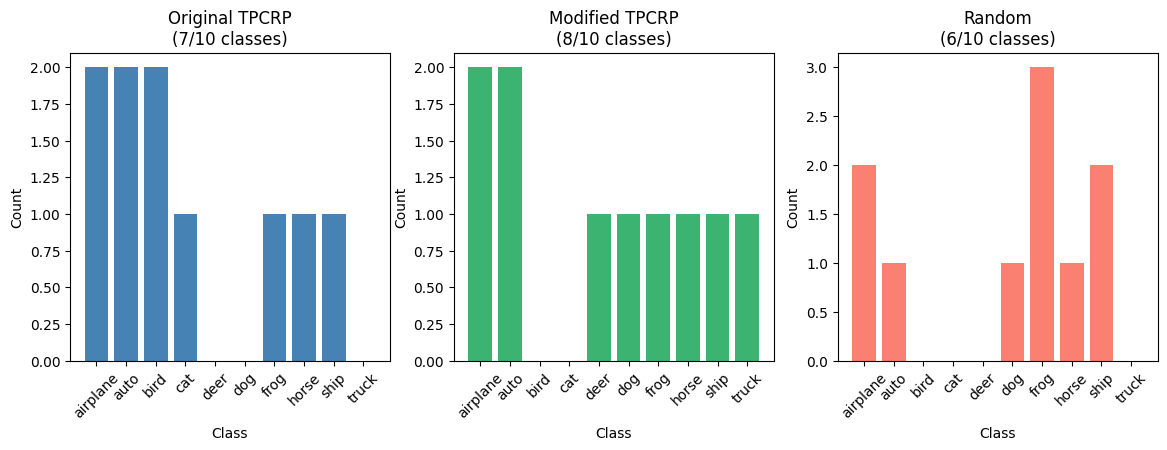

Plot 1 saved
Running t-SNE (~1 min)...


/tmp/ipykernel_55/2573923106.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


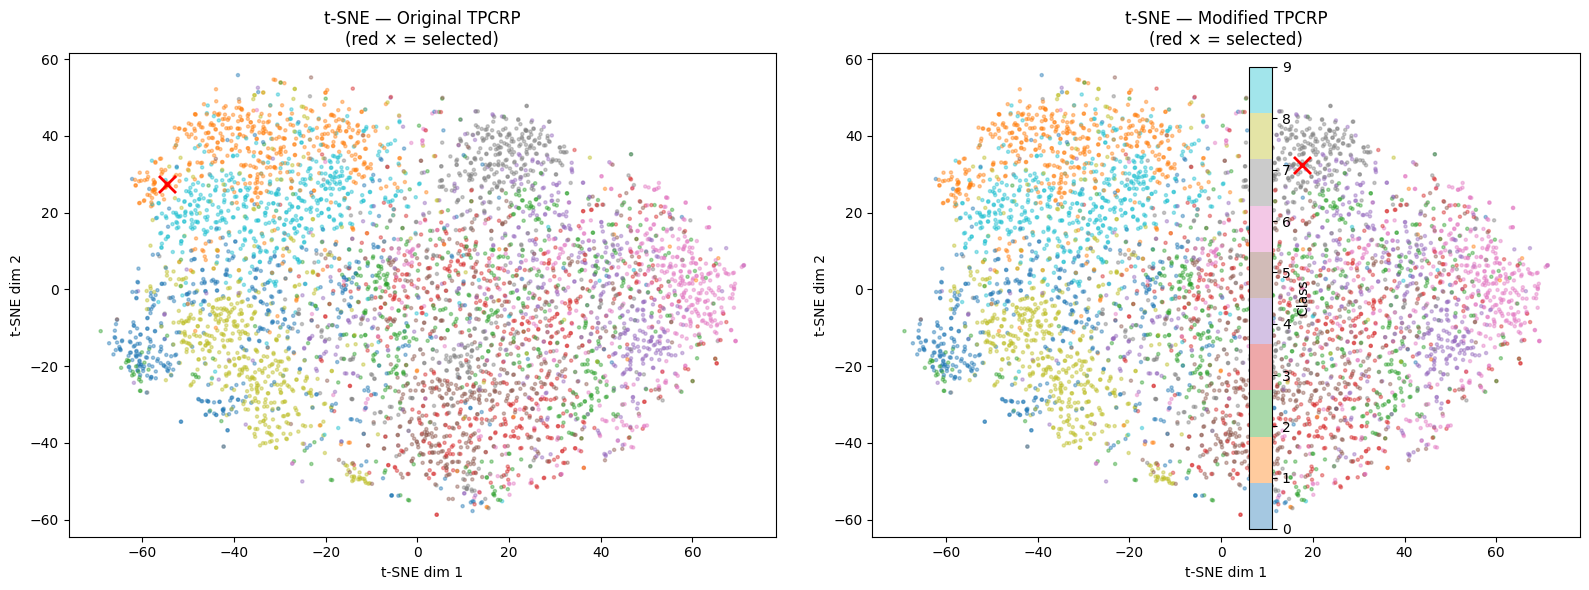

Plot 2 saved


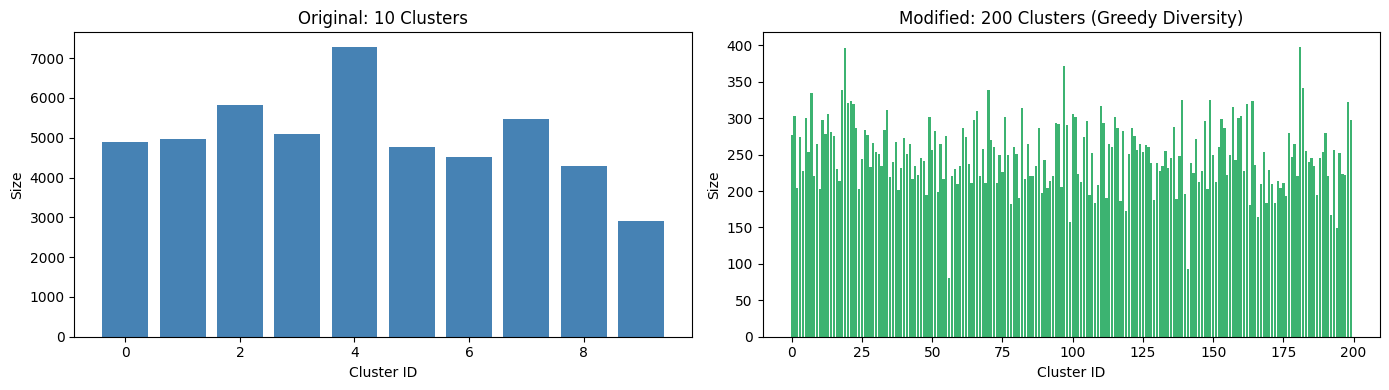

Plot 3 saved


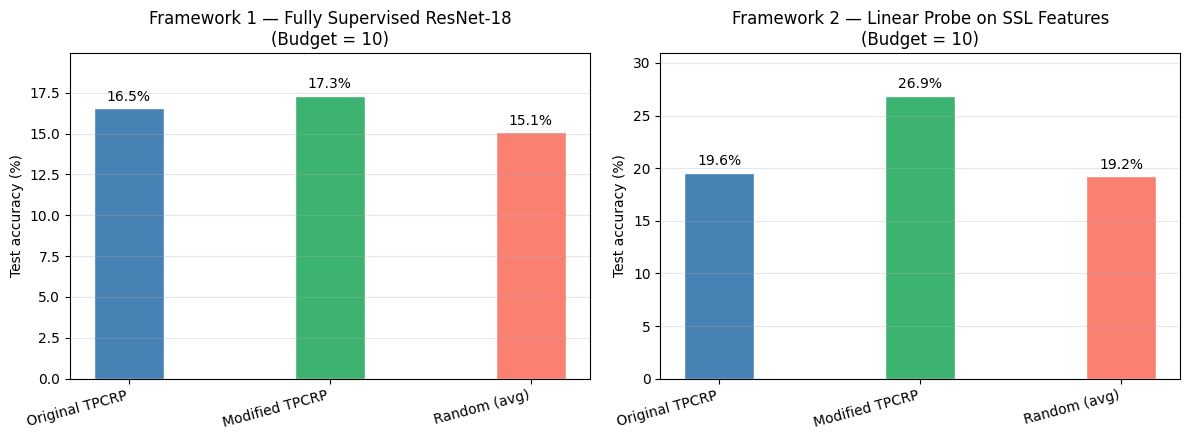

Plot 4 saved

Method                  Classes   Labels
-------------------------------------------------------
Original TPCRP                7   [0, 1, 2, 3, 6, 7, 8]
Modified TPCRP                8   [0, 1, 4, 5, 6, 7, 8, 9]
Random                        6   [0, 1, 5, 6, 7, 8]


In [24]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

BUDGET = 10
CIFAR10_CLASSES = ['airplane','auto','bird','cat','deer','dog','frog','horse','ship','truck']

np.random.seed(42)
random_indices = np.random.choice(len(base_dataset), size=BUDGET, replace=False)
random_labels_list = [base_dataset[i][1] for i in random_indices]

# ── Plot 1: Class Distribution (3-way) ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, lbls, title, color in zip(
    axes,
    [selected_labels, selected_labels_mod, random_labels_list],
    ['Original TPCRP', 'Modified TPCRP', 'Random'],
    ['steelblue', 'mediumseagreen', 'salmon']
):
    counts = [lbls.count(i) for i in range(10)]
    ax.bar(CIFAR10_CLASSES, counts, color=color)
    ax.set_title(f"{title}\n({len(set(lbls))}/10 classes)")
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.subplots_adjust(right=0.85)
plt.savefig('/kaggle/working/class_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved")

# ── Plot 2: t-SNE (original vs modified) ──────────────────────────────────────
print("Running t-SNE (~1 min)...")
np.random.seed(42)
idx_sub = np.random.choice(len(embeddings), size=5000, replace=False)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(embeddings[idx_sub])
lbl_sub = true_labels[idx_sub]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, sel_idx, title in zip(
    axes,
    [selected_indices, selected_indices_mod],
    ['Original TPCRP', 'Modified TPCRP']
):
    sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=lbl_sub, cmap='tab10', s=5, alpha=0.4)
    for gi in sel_idx:
        pos = np.where(idx_sub == gi)[0]
        if len(pos):
            ax.scatter(emb_2d[pos[0], 0], emb_2d[pos[0], 1],
                       c='red', s=150, marker='x', linewidths=2, zorder=5)
    ax.set_title(f't-SNE — {title}\n(red × = selected)')
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
plt.colorbar(sc, ax=axes, label='Class')
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved")

# ── Plot 3: Cluster sizes ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(10), np.bincount(cluster_labels), color='steelblue')
axes[0].set_title('Original: 10 Clusters')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Size')

sizes_mod = np.bincount(cluster_labels_mod)
axes[1].bar(range(200), sizes_mod, color='mediumseagreen')
axes[1].set_title('Modified: 200 Clusters (Greedy Diversity)')
axes[1].set_xlabel('Cluster ID')
axes[1].set_ylabel('Size')
plt.tight_layout()
plt.savefig('/kaggle/working/cluster_sizes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved")

# ── Plot 4: Accuracy vs Budget ─────────────────────────────────────────────────
methods = ['Original TPCRP', 'Modified TPCRP', 'Random (avg)']
colors  = ['steelblue', 'mediumseagreen', 'salmon']
x       = np.arange(len(methods))
width   = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, accs, title in zip(
    axes,
    [(acc_orig_fs, acc_mod_fs, acc_random_fs),
     (acc_orig_lp, acc_mod_lp, acc_random_lp)],
    ['Framework 1 — Fully Supervised ResNet-18',
     'Framework 2 — Linear Probe on SSL Features']
):
    bars = ax.bar(x, accs, color=colors, width=width, edgecolor='white')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=15, ha='right')
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title(f'{title}\n(Budget = 10)')
    ax.set_ylim(0, max(accs) * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved")
# ── Summary ────────────────────────────────────────────────────────────────────
print(f"\n{'Method':<22} {'Classes':>8}   Labels")
print("-" * 55)
print(f"{'Original TPCRP':<22} {len(set(selected_labels)):>8}   {sorted(set(selected_labels))}")
print(f"{'Modified TPCRP':<22} {len(set(selected_labels_mod)):>8}   {sorted(set(selected_labels_mod))}")
print(f"{'Random':<22} {len(set(random_labels_list)):>8}   {sorted(set(random_labels_list))}")

